In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Chemin vers le dossier contenant les CSV
data_folder = "../data/processed"

# Liste des fichiers par poste
files = [
    "nba_pg_clusters_full.csv",
    "nba_sg_clusters_full.csv",
    "nba_sf_clusters_full.csv",
    "nba_pf_clusters_full.csv",
    "nba_c_clusters_full.csv"
]

# Créer le chemin complet pour chaque fichier
file_paths = [os.path.join(data_folder, f) for f in files]

# Vérifier que les fichiers existent
for f in file_paths:
    print(f, os.path.exists(f))  # True = fichier trouvé

# Charger tous les CSV et concaténer
dfs = [pd.read_csv(f) for f in file_paths]
nba_all = pd.concat(dfs, ignore_index=True)

# Vérification
print(nba_all.shape)
nba_all.head()


../data/processed\nba_pg_clusters_full.csv True
../data/processed\nba_sg_clusters_full.csv True
../data/processed\nba_sf_clusters_full.csv True
../data/processed\nba_pf_clusters_full.csv True
../data/processed\nba_c_clusters_full.csv True
(6708, 30)


,season,player,player_id,age,team,pos,g,gs,mp,per,...,usg_percent,ows,dws,ws,ws_48,obpm,dbpm,bpm,vorp,cluster
0,2026,Jose Alvarado,alvarjo01,27.0,NOP,PG,32,0.0,713.0,11.8,...,15.8,0.5,0.3,0.8,0.052,-1.4,-0.5,-1.9,0.0,0
1,2026,LaMelo Ball,ballla01,24.0,CHO,PG,23,23.0,653.0,19.2,...,32.8,0.7,0.5,1.2,0.087,3.7,-1.2,2.5,0.8,1
2,2026,Lonzo Ball,balllo01,28.0,CLE,PG,25,3.0,581.0,9.5,...,13.7,-0.3,0.8,0.5,0.042,-3.1,1.4,-1.7,0.0,2
3,2026,Anthony Black,blackan01,22.0,ORL,PG,34,14.0,1012.0,13.8,...,22.7,0.1,1.3,1.4,0.068,-1.2,0.8,-0.4,0.4,0
4,2026,Jalen Brunson,brunsja01,29.0,NYK,PG,30,30.0,1064.0,22.5,...,31.6,3.6,0.6,4.2,0.188,5.5,-1.8,3.7,1.5,1


In [2]:
composition = (
    nba_all
    .groupby(['season', 'pos', 'cluster'])
    .size()
    .reset_index(name='count')
)

# Calcul du pourcentage par poste/saison
composition['percent'] = composition.groupby(['season','pos'])['count'].transform(lambda x: 100*x/x.sum())

print(composition.head(20))


    season pos  cluster  count    percent
0     2010   C        0     15  21.428571
1     2010   C        1     43  61.428571
2     2010   C        2      8  11.428571
3     2010   C        3      4   5.714286
4     2010  PF        0     39  51.315789
5     2010  PF        1     26  34.210526
6     2010  PF        2     11  14.473684
7     2010  PG        0     27  32.142857
8     2010  PG        1     23  27.380952
9     2010  PG        2     34  40.476190
10    2010  SF        0     34  47.887324
11    2010  SF        1     17  23.943662
12    2010  SF        2     13  18.309859
13    2010  SF        3      7   9.859155
14    2010  SG        0     29  35.802469
15    2010  SG        1     29  35.802469
16    2010  SG        2     23  28.395062
17    2011   C        0      8  10.526316
18    2011   C        1     59  77.631579
19    2011   C        2      7   9.210526


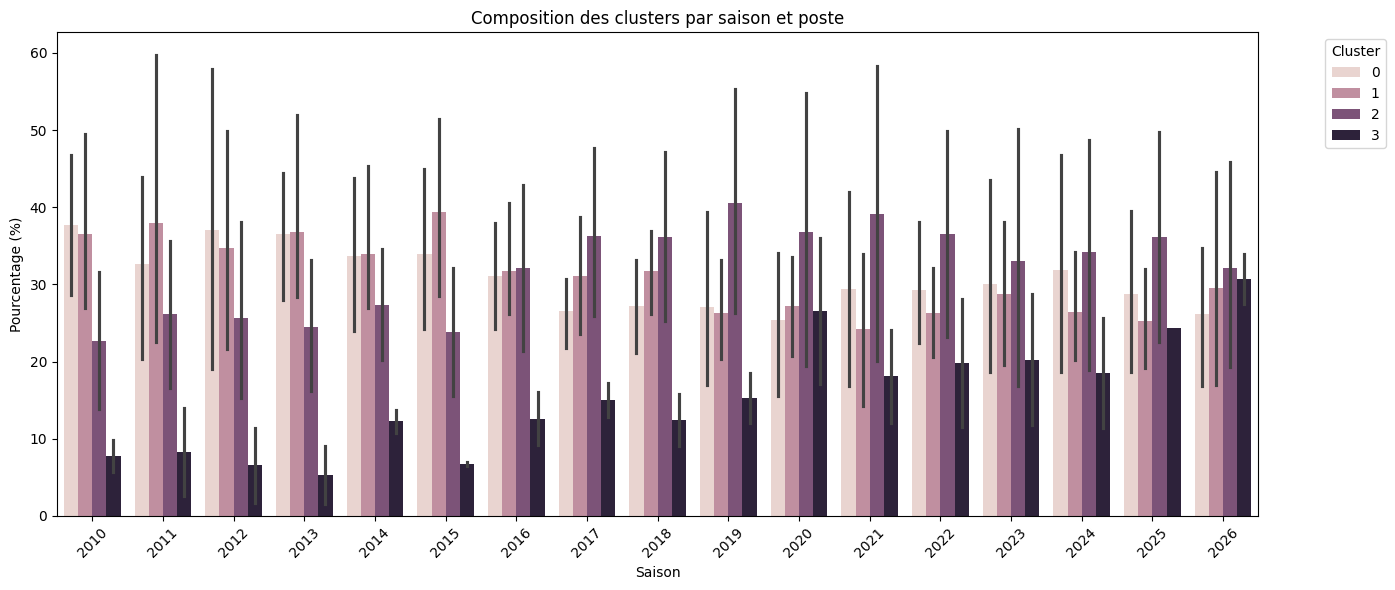

In [3]:
plt.figure(figsize=(14,6))
sns.barplot(
    data=composition,
    x='season',
    y='percent',
    hue='cluster'
)
plt.title("Composition des clusters par saison et poste")
plt.ylabel("Pourcentage (%)")
plt.xlabel("Saison")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
win_pct_2010 = {"LAL": 0.695, "DAL": 0.671, "PHX": 0.659, "UTA": 0.646, "DEN": 0.646, "SAS": 0.610, "OKC": 0.610, "POR": 0.610, "HOU": 0.512, "MEM": 0.488, "NOP": 0.451, "LAC": 0.354, "GSW": 0.317, "SAC": 0.305, "MIN": 0.183, "CLE": 0.744, "ORL": 0.720, "ATL": 0.646, "BOS": 0.610, "MIA": 0.573, "MIL": 0.561, "CHA": 0.537, "CHI": 0.500, "TOR": 0.488, "IND": 0.390, "NYK": 0.354, "PHI": 0.329, "DET": 0.329, "WAS": 0.317, "BKN": 0.146}
win_pct_2011 = {"SAS": 0.744, "LAL": 0.695, "OKC": 0.671, "DAL": 0.695, "DEN": 0.610, "POR": 0.585, "NOP": 0.561, "MEM": 0.561, "HOU": 0.524, "PHX": 0.488, "UTA": 0.476, "GSW": 0.439, "LAC": 0.390, "SAC": 0.293, "MIN": 0.207, "CHI": 0.756, "MIA": 0.707, "BOS": 0.683, "ORL": 0.634, "ATL": 0.537, "NYK": 0.512, "PHI": 0.500, "IND": 0.451, "MIL": 0.427, "CHA": 0.415, "DET": 0.366, "BKN": 0.293, "WAS": 0.280, "TOR": 0.268, "CLE": 0.232}
win_pct_2012 = {"SAS": 0.758, "OKC": 0.712, "LAL": 0.621, "MEM": 0.621, "LAC": 0.606, "DEN": 0.576, "DAL": 0.545, "UTA": 0.545, "HOU": 0.515, "PHX": 0.500, "POR": 0.424, "MIN": 0.394, "GSW": 0.348, "SAC": 0.333, "NOP": 0.318, "CHI": 0.758, "MIA": 0.697, "BOS": 0.591, "IND": 0.636, "ATL": 0.606, "ORL": 0.561, "NYK": 0.545, "PHI": 0.530, "MIL": 0.470, "DET": 0.379, "TOR": 0.348, "BKN": 0.333, "CLE": 0.318, "WAS": 0.303, "CHA": 0.106}
win_pct_2013 = {"OKC": 0.732, "SAS": 0.707, "LAC": 0.683, "DEN": 0.695, "MEM": 0.683, "GSW": 0.573, "LAL": 0.549, "HOU": 0.549, "UTA": 0.524, "DAL": 0.500, "POR": 0.402, "MIN": 0.378, "SAC": 0.341, "NOP": 0.329, "PHX": 0.305, "MIA": 0.805, "NYK": 0.659, "IND": 0.605, "BKN": 0.598, "CHI": 0.549, "ATL": 0.537, "BOS": 0.506, "MIL": 0.463, "PHI": 0.415, "TOR": 0.415, "DET": 0.354, "WAS": 0.354, "CLE": 0.293, "CHA": 0.256, "ORL": 0.244}
win_pct_2014 = {"SAS": 0.756, "OKC": 0.720, "LAC": 0.695, "HOU": 0.659, "POR": 0.659, "GSW": 0.622, "MEM": 0.610, "DAL": 0.598, "PHX": 0.585, "MIN": 0.488, "DEN": 0.439, "NOP": 0.415, "SAC": 0.341, "LAL": 0.329, "UTA": 0.305, "IND": 0.683, "MIA": 0.659, "TOR": 0.585, "CHI": 0.585, "WAS": 0.537, "BKN": 0.537, "CHA": 0.524, "ATL": 0.463, "NYK": 0.451, "CLE": 0.402, "DET": 0.354, "BOS": 0.305, "ORL": 0.280, "PHI": 0.232, "MIL": 0.183}
win_pct_2015 = {"GSW": 0.817, "HOU": 0.683, "POR": 0.622, "LAC": 0.683, "MEM": 0.671, "SAS": 0.671, "DAL": 0.610, "NOP": 0.549, "OKC": 0.549, "PHX": 0.476, "UTA": 0.463, "DEN": 0.366, "SAC": 0.354, "LAL": 0.256, "MIN": 0.195, "ATL": 0.732, "CLE": 0.646, "TOR": 0.598, "CHI": 0.610, "WAS": 0.561, "MIL": 0.500, "BOS": 0.488, "IND": 0.463, "BKN": 0.463, "MIA": 0.451, "CHA": 0.402, "DET": 0.390, "ORL": 0.305, "PHI": 0.220, "NYK": 0.207}
win_pct_2016 = {"GSW": 0.890, "SAS": 0.817, "OKC": 0.671, "LAC": 0.646, "POR": 0.537, "DAL": 0.512, "MEM": 0.512, "HOU": 0.500, "UTA": 0.488, "SAC": 0.402, "DEN": 0.402, "NOP": 0.366, "MIN": 0.354, "PHX": 0.280, "LAL": 0.207, "CLE": 0.695, "TOR": 0.683, "MIA": 0.585, "ATL": 0.585, "BOS": 0.585, "CHA": 0.585, "IND": 0.549, "DET": 0.537, "CHI": 0.512, "WAS": 0.500, "ORL": 0.427, "MIL": 0.402, "NYK": 0.390, "BKN": 0.256, "PHI": 0.122}
win_pct_2017 = {"GSW": 0.817, "SAS": 0.744, "HOU": 0.671, "LAC": 0.622, "UTA": 0.622, "OKC": 0.573, "MEM": 0.524, "POR": 0.500, "DEN": 0.488, "NOP": 0.415, "DAL": 0.402, "SAC": 0.390, "MIN": 0.378, "LAL": 0.317, "PHX": 0.293, "BOS": 0.646, "TOR": 0.622, "CLE": 0.622, "WAS": 0.598, "ATL": 0.524, "MIL": 0.512, "IND": 0.512, "MIA": 0.500, "CHI": 0.500, "DET": 0.451, "CHA": 0.439, "NYK": 0.378, "ORL": 0.354, "PHI": 0.341, "BKN": 0.244}
win_pct_2018 = {"HOU": 0.793, "GSW": 0.707, "POR": 0.598, "UTA": 0.585, "OKC": 0.585, "NOP": 0.585, "SAS": 0.573, "MIN": 0.573, "DEN": 0.561, "LAC": 0.512, "LAL": 0.427, "SAC": 0.329, "DAL": 0.293, "MEM": 0.268, "PHX": 0.256, "TOR": 0.720, "BOS": 0.671, "PHI": 0.634, "CLE": 0.610, "IND": 0.585, "MIA": 0.537, "MIL": 0.537, "WAS": 0.524, "DET": 0.476, "CHA": 0.439, "NYK": 0.354, "BKN": 0.341, "CHI": 0.329, "ORL": 0.305, "ATL": 0.293}
win_pct_2019 = {"GSW": 0.695, "DEN": 0.659, "POR": 0.646, "HOU": 0.646, "UTA": 0.610, "OKC": 0.598, "SAS": 0.585, "LAC": 0.585, "SAC": 0.476, "LAL": 0.451, "MIN": 0.439, "MEM": 0.402, "NOP": 0.402, "DAL": 0.402, "PHX": 0.232, "MIL": 0.732, "TOR": 0.707, "PHI": 0.622, "BOS": 0.598, "IND": 0.585, "BKN": 0.512, "ORL": 0.512, "DET": 0.500, "CHA": 0.476, "MIA": 0.476, "WAS": 0.390, "ATL": 0.354, "CHI": 0.268, "CLE": 0.232, "NYK": 0.207}
win_pct_2020 = {"LAL": 0.732, "LAC": 0.681, "DEN": 0.630, "HOU": 0.611, "UTA": 0.611, "OKC": 0.611, "DAL": 0.573, "POR": 0.473, "MEM": 0.466, "PHX": 0.466, "SAS": 0.451, "SAC": 0.431, "NOP": 0.417, "MIN": 0.297, "GSW": 0.231, "MIL": 0.767, "TOR": 0.736, "BOS": 0.667, "IND": 0.616, "MIA": 0.603, "PHI": 0.589, "BKN": 0.486, "ORL": 0.452, "CHA": 0.354, "WAS": 0.347, "CHI": 0.338, "NYK": 0.318, "DET": 0.303, "ATL": 0.299, "CLE": 0.292}
win_pct_2021 = {"UTA": 0.722, "PHX": 0.708, "DEN": 0.653, "LAC": 0.653, "DAL": 0.583, "POR": 0.583, "LAL": 0.583, "MEM": 0.528, "GSW": 0.542, "SAS": 0.458, "NOP": 0.431, "SAC": 0.431, "MIN": 0.319, "OKC": 0.306, "HOU": 0.236, "PHI": 0.681, "BKN": 0.667, "MIL": 0.639, "NYK": 0.569, "ATL": 0.569, "MIA": 0.556, "BOS": 0.500, "WAS": 0.472, "IND": 0.472, "CHA": 0.458, "CHI": 0.431, "TOR": 0.375, "CLE": 0.306, "ORL": 0.292, "DET": 0.278}
win_pct_2022 = {"PHX":0.780,"MEM":0.683,"GSW":0.646,"DAL":0.634,"UTA":0.598,"DEN":0.585,"MIN":0.561,"NOP":0.439,"LAC":0.512,"SAS":0.415,"LAL":0.402,"SAC":0.366,"POR":0.329,"OKC":0.293,"HOU":0.244,"MIA":0.646,"BOS":0.622,"MIL":0.622,"PHI":0.622,"TOR":0.585,"CHI":0.561,"BKN":0.537,"ATL":0.524,"CLE":0.537,"CHA":0.524,"NYK":0.451,"WAS":0.427,"IND":0.305,"DET":0.280,"ORL":0.268}
win_pct_2023 = {"DEN":0.646,"MEM":0.622,"SAC":0.585,"PHX":0.549,"LAC":0.537,"GSW":0.537,"LAL":0.524,"MIN":0.512,"NOP":0.512,"OKC":0.488,"DAL":0.463,"UTA":0.451,"POR":0.402,"HOU":0.268,"SAS":0.268,"MIL":0.707,"BOS":0.695,"PHI":0.659,"CLE":0.622,"NYK":0.573,"BKN":0.549,"MIA":0.537,"ATL":0.500,"TOR":0.500,"CHI":0.488,"WAS":0.427,"IND":0.427,"ORL":0.415,"CHA":0.329,"DET":0.207}
win_pct_2024 = {"OKC":0.695,"DEN":0.695,"MIN":0.683,"LAC":0.622,"DAL":0.610,"PHX":0.598,"NOP":0.598,"LAL":0.573,"SAC":0.561,"GSW":0.561,"HOU":0.500,"UTA":0.378,"MEM":0.329,"SAS":0.268,"POR":0.256,"BOS":0.780,"NYK":0.610,"MIL":0.598,"CLE":0.585,"ORL":0.573,"IND":0.573,"PHI":0.573,"MIA":0.561,"CHI":0.476,"ATL":0.439,"BKN":0.390,"TOR":0.305,"CHA":0.256,"WAS":0.183,"DET":0.171}
win_pct_2025 = {"OKC":0.829,"HOU":0.634,"LAL":0.610,"DEN":0.610,"LAC":0.610,"MIN":0.598,"GSW":0.585,"MEM":0.585,"SAC":0.488,"DAL":0.476,"PHX":0.439,"POR":0.439,"SAS":0.415,"NOP":0.256,"UTA":0.207,"CLE":0.780,"BOS":0.744,"NYK":0.622,"IND":0.610,"MIL":0.585,"DET":0.537,"ORL":0.500,"ATL":0.488,"CHI":0.476,"MIA":0.451,"TOR":0.366,"BKN":0.317,"PHI":0.293,"CHA":0.232,"WAS":0.220}
win_pct_2026 = {"OKC":0.818,"SAS":0.682,"DEN":0.659,"HOU":0.634,"LAL":0.619,"MIN":0.614,"PHX":0.614,"GSW":0.556,"POR":0.500,"LAC":0.442,"MEM":0.439,"DAL":0.409,"UTA":0.341,"SAC":0.273,"NOP":0.222,"DET":0.756,"BOS":0.619,"NYK":0.581,"TOR":0.578,"PHI":0.548,"ORL":0.548,"CLE":0.545,"MIA":0.523,"CHI":0.488,"ATL":0.444,"MIL":0.429,"CHA":0.372,"BKN":0.293,"WAS":0.238,"IND":0.227}


In [5]:
# Supposons que ton df "nba_all" a une colonne "Team" avec les abréviations comme "LAL", "DAL", etc.

# Liste de toutes tes saisons/dictionnaires
seasons = ["2010", "2011", "2012", "2013", "2014", "2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025"]

# Boucle pour ajouter chaque dictionnaire comme une colonne
for season in seasons:
    dict_name = f"win_pct_{season}"           # Exemple : "win_pct_2010"
    nba_all[f"win_pct_{season}"] = nba_all["team"].map(globals()[dict_name])


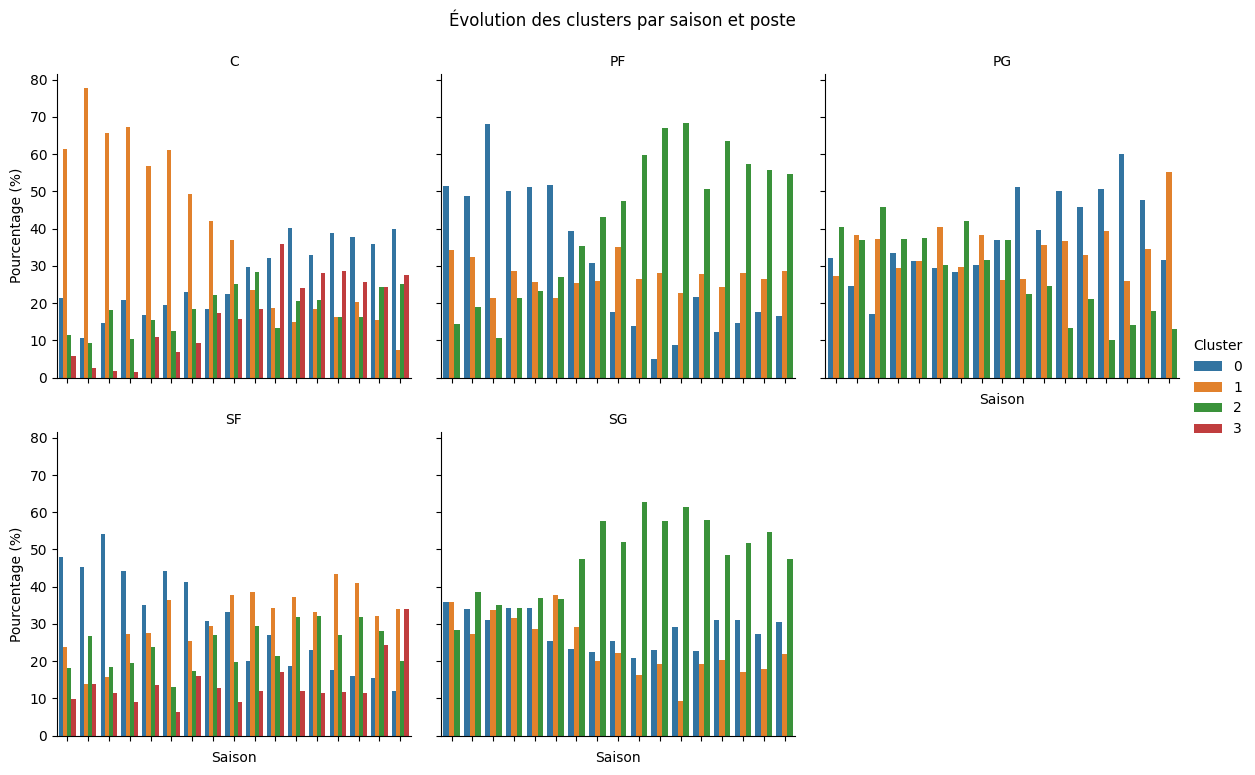

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assurer que la colonne 'season' est bien triée
composition['season'] = composition['season'].astype(str)  # pour un affichage correct

# FacetGrid : un graphique par poste
g = sns.FacetGrid(composition, col='pos', col_wrap=3, height=4, sharey=True)
g.map_dataframe(
    sns.barplot,
    x='season',
    y='percent',
    hue='cluster',
    palette='tab10',
    order=sorted(composition['season'].unique())
)

# Ajustements esthétiques
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Saison", "Pourcentage (%)")
g.set_xticklabels(rotation=45)
g.add_legend(title="Cluster")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Évolution des clusters par saison et poste")
plt.show()


In [7]:
import plotly.express as px

df_pg = composition[composition['pos'] == 'PG']

fig_pg = px.bar(
    df_pg,
    x='season',
    y='percent',
    color='cluster',
    hover_data={'count': True, 'percent': ':.1f', 'cluster': True, 'season': True},
    labels={'percent':'Pourcentage (%)', 'season':'Saison', 'cluster_name':'Cluster'},
    title='Évolution des clusters PG par saison',
    height=500,
    width=900
)
fig_pg.update_layout(barmode='stack', legend_title_text='Cluster')
fig_pg.update_traces(marker_line_width=0.5, marker_line_color='black')
fig_pg.show()


In [8]:
df_sg = composition[composition['pos'] == 'SG']

fig_sg = px.bar(
    df_sg,
    x='season',
    y='percent',
    color='cluster',
    hover_data={'count': True, 'percent': ':.1f', 'cluster': True, 'season': True},
    labels={'percent':'Pourcentage (%)', 'season':'Saison', 'cluster_name':'Cluster'},
    title='Évolution des clusters SG par saison',
    height=500,
    width=900
)
fig_sg.update_layout(barmode='stack', legend_title_text='Cluster')
fig_sg.update_traces(marker_line_width=0.5, marker_line_color='black')
fig_sg.show()

In [9]:
df_sf = composition[composition['pos'] == 'SF']

fig_sf = px.bar(
    df_sf,
    x='season',
    y='percent',
    color='cluster',
    hover_data={'count': True, 'percent': ':.1f', 'cluster': True, 'season': True},
    labels={'percent':'Pourcentage (%)', 'season':'Saison', 'cluster_name':'Cluster'},
    title='Évolution des clusters SF par saison',
    height=500,
    width=900
)
fig_sf.update_layout(barmode='stack', legend_title_text='Cluster')
fig_sf.update_traces(marker_line_width=0.5, marker_line_color='black')
fig_sf.show()


In [10]:
df_pf = composition[composition['pos'] == 'PF']

fig_pf = px.bar(
    df_pf,
    x='season',
    y='percent',
    color='cluster',
    hover_data={'count': True, 'percent': ':.1f', 'cluster': True, 'season': True},
    labels={'percent':'Pourcentage (%)', 'season':'Saison', 'cluster_name':'Cluster'},
    title='Évolution des clusters PF par saison',
    height=500,
    width=900
)
fig_pf.update_layout(barmode='stack', legend_title_text='Cluster')
fig_pf.update_traces(marker_line_width=0.5, marker_line_color='black')
fig_pf.show()


In [11]:
df_c = composition[composition['pos'] == 'C']

fig_c = px.bar(
    df_c,
    x='season',
    y='percent',
    color='cluster',
    hover_data={'count': True, 'percent': ':.1f', 'cluster': True, 'season': True},
    labels={'percent':'Pourcentage (%)', 'season':'Saison', 'cluster_name':'Cluster'},
    title='Évolution des clusters C par saison',
    height=500,
    width=900
)
fig_c.update_layout(barmode='stack', legend_title_text='Cluster')
fig_c.update_traces(marker_line_width=0.5, marker_line_color='black')
fig_c.show()


In [12]:
# Extraire les 5 équipes avec le meilleur win %
top5_2010 = sorted(win_pct_2010.items(), key=lambda x: x[1], reverse=True)[:5]
top5_teams_2010 = [team for team, pct in top5_2010]
print(top5_teams_2010)


['CLE', 'ORL', 'LAL', 'DAL', 'PHX']


In [14]:
df_2010 = nba_all[nba_all['season'] == 2010]
df_top5_2010 = df_2010[df_2010['team'].isin(top5_teams_2010)]


In [22]:
composition_2010 = (
    df_top5_2010
    .groupby(['pos', 'cluster'])
    .size()
    .reset_index(name='count')
)

# Calcul des proportions par poste
totals = composition_2010.groupby('pos')['count'].transform('sum')
composition_2010['proportion'] = composition_2010['count'] / totals


In [23]:
pivot_2010 = composition_2010.pivot(index='pos', columns='cluster', values='proportion')


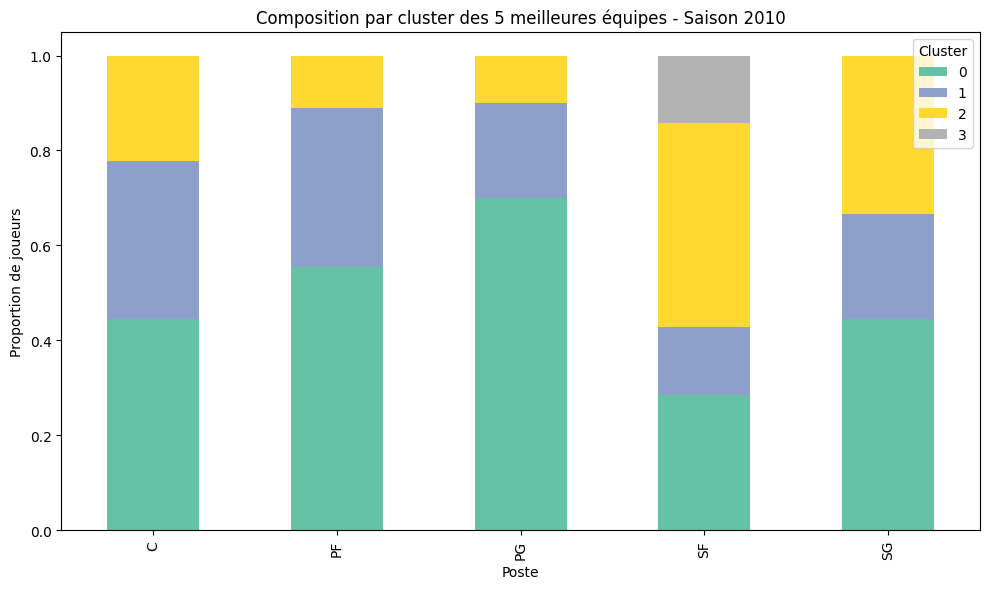

In [24]:
import matplotlib.pyplot as plt

pivot_2010.plot(kind='bar', stacked=True, colormap='Set2', figsize=(10,6))
plt.title("Composition par cluster des 5 meilleures équipes - Saison 2010")
plt.xlabel("Poste")
plt.ylabel("Proportion de joueurs")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


In [20]:
composition_2010 = (
    df_top5_2010
    .groupby(['pos', 'cluster'])['mp']  # minutes jouées
    .sum()
    .reset_index(name='total_minutes')
)

# Proportion par poste pondérée
totals = composition_2010.groupby('pos')['total_minutes'].transform('sum')
composition_2010['proportion'] = composition_2010['total_minutes'] / totals


<Figure size 1000x600 with 0 Axes>

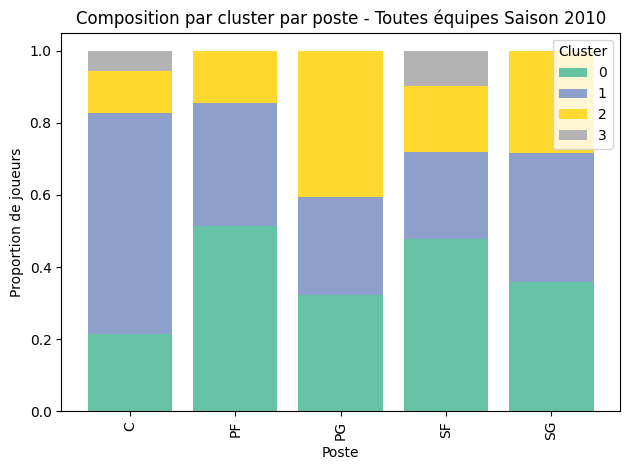

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1️⃣ Filtrer la saison 2010 ---
df_2010 = nba_all[nba_all['season'] == 2010]

# --- 2️⃣ Calculer la composition par cluster pour chaque poste ---
composition_2010 = (
    df_2010
    .groupby(['pos', 'cluster'])
    .size()
    .reset_index(name='count')
)

# Calcul des proportions par poste
totals = composition_2010.groupby('pos')['count'].transform('sum')
composition_2010['proportion'] = composition_2010['count'] / totals

# --- 3️⃣ Pivot pour faciliter le graphique ---
pivot_2010 = composition_2010.pivot(index='pos', columns='cluster', values='proportion').fillna(0)

# --- 4️⃣ Graphique en barre empilée ---
plt.figure(figsize=(10,6))
pivot_2010.plot(kind='bar', stacked=True, colormap='Set2', width=0.8)
plt.title("Composition par cluster par poste - Toutes équipes Saison 2010")
plt.xlabel("Poste")
plt.ylabel("Proportion de joueurs")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()
